In [1]:
# Load LeafletSC 
import LeafletSC
import os
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

# Define path that contains junction files
juncs_path = "/gpfs/commons/datasets/controlled/BRAIN_NeMO/human-cortex-mtg/Leaflet/"
print("The junctions are loaded from the following path: " + juncs_path) 

# print the files in the path 
print("The files in the path are: " + str(os.listdir(juncs_path)))

# define path for saving the output data 
output_path = "/gpfs/commons/datasets/controlled/BRAIN_NeMO/human-cortex-mtg/LeafletAnalysis/"

# we provide a gtf file for the human genome as well to make better sense of the junctions that are detected in cells
# please replace with the path to the gtf file on your system
gtf_file="/gpfs/commons/datasets/controlled/BRAIN_NeMO/human-reference/gencode/gencode.v45.primary_assembly.annotation.gtf" 

# file with cell gene expression based leiden clusters 
cells_ge = "/gpfs/commons/datasets/controlled/BRAIN_NeMO/human-cortex-mtg/mtg_nuclei_gene_expression_leiden_clusters.csv"

# published metadata
metacells = "/gpfs/commons/datasets/controlled/BRAIN_NeMO/human-cortex-mtg/human_MTG_2018-06-14_samples-columns.csv"

The junctions are loaded from the following path: /gpfs/commons/datasets/controlled/BRAIN_NeMO/human-cortex-mtg/Leaflet/
The files in the path are: ['F2S4_170405_009_B01_junctions.bed', 'F2S4_170405_005_C01_junctions.bed', 'F2S4_170405_016_C01_barcodes.txt', 'F2S4_170405_012_E01_barcodes.txt', 'F2S4_170405_013_D01_junctions.bed', 'F2S4_170405_009_E01_barcodes.txt', 'F2S4_170405_012_A01_junctions.bed', 'F2S4_170405_020_E01_junctions.bed', 'F2S4_170405_006_F01_junctions_with_barcodes.bed', 'F2S4_170405_014_H01_junctions.bed', 'F2S4_170405_032_E01_barcodes.txt', 'F2S4_170405_023_G01_junctions_with_barcodes.bed', 'F2S4_170405_019_H01_junctions_with_barcodes.bed', 'F2S4_170405_030_A01_junctions_with_barcodes.bed', 'F2S4_170405_021_A01_junctions_with_barcodes.bed', 'F2S4_170405_026_G01_barcodes.txt', 'F2S4_170405_018_E01_junctions.bed', 'F2S4_170405_013_A01_barcodes.txt', 'F2S4_170405_012_C01_barcodes.txt', 'F2S4_170405_017_G01_barcodes.txt', 'F2S4_170405_020_B01_junctions.bed', 'F2S4_170405

In [2]:
# read in metacells 
cells_pub = pd.read_csv(metacells)
cells_pub.head()

,sample_name,sample_id,sample_type,organism,donor,sex,age_days,brain_hemisphere,brain_region,brain_subregion,...,percent_mt_exon_reads,percent_reads_unique,percent_synth_reads,percent_ecoli_reads,percent_aligned_reads_total,complexity_cg,genes_detected_cpm_criterion,genes_detected_fpkm_criterion,class,cluster
0,F1S4_160106_001_B01,556012415,Nuclei,Homo sapiens,H200.1030,M,19710,L,MTG,L5,...,0.090052,85.573696,0.007535,0.018537,92.418885,0.316637,8635,5253,GABAergic,Inh L4-6 SST B3GAT2
1,F1S4_160106_001_C01,556012410,Nuclei,Homo sapiens,H200.1030,M,19710,L,MTG,L5,...,0.052470,87.619777,0.002790,0.007265,94.001319,0.287989,11697,8246,Glutamatergic,Exc L5-6 RORB TTC12
2,F1S4_160106_001_E01,556012412,Nuclei,Homo sapiens,H200.1030,M,19710,L,MTG,L5,...,0.042946,86.448562,0.004573,0.006413,92.871217,0.280933,12138,8467,Glutamatergic,Exc L5-6 FEZF2 ABO
3,F1S4_160106_001_G01,556012414,Nuclei,Homo sapiens,H200.1030,M,19710,L,MTG,L5,...,0.055851,84.497105,0.006585,0.008131,90.198132,0.293406,12191,8287,Glutamatergic,Exc L5-6 FEZF2 EFTUD1P1
4,F1S4_160106_001_H01,556012409,Nuclei,Homo sapiens,H200.1030,M,19710,L,MTG,L5,...,0.055692,87.014752,0.005061,0.011116,93.460676,0.293106,10535,6922,Glutamatergic,Exc L3-5 RORB ESR1


In [3]:
# read in cells_ge, the first column is index values for rows 
cells_ge = pd.read_csv(cells_ge, index_col=0, sep="\t")
cells_ge.head()

,cell_id_1,cell_id_2,cell_id_3,cell_id_4,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,...,leiden_res_2.00,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb
F2S4_170405_031_D01,F2S4,170405,31,D01,7933,8.978913,32734.580,10.396218,1.202006,2.293659,...,0,2.543117,1.265007,0.007769,216.30637,5.381308,0.660789,12.582603,2.608790,0.038438
F2S4_170405_019_A01,F2S4,170405,19,A01,6359,8.757784,26248.543,10.175404,1.506312,2.894703,...,1,0.000000,0.000000,0.000000,177.77026,5.186101,0.677258,5.126597,1.812639,0.019531
F2S4_170405_027_B01,F2S4,170405,27,B01,6746,8.816853,28458.307,10.256230,1.406242,2.687740,...,2,12.247885,2.583838,0.043038,199.17482,5.299191,0.699883,3.744765,1.557042,0.013159
F2S4_170405_029_A01,F2S4,170405,29,A01,5983,8.696845,25351.123,10.140617,1.585121,3.024181,...,1,14.157266,2.718480,0.055845,182.38692,5.211598,0.719443,8.975893,2.300171,0.035406
F2S4_170405_008_C01,F2S4,170405,8,C01,5935,8.688791,24877.955,10.121778,1.617751,3.097633,...,3,4.981633,1.788694,0.020024,149.60520,5.014662,0.601356,3.531000,1.510943,0.014193


In [4]:
# find index corresponding to "F2S4_170405_031_D01" row in cells_ge
cells_ge["sample_name"] = cells_ge.index.values
cells_ge[cells_ge["sample_name"] == "F2S4_170405_031_D01"]

,cell_id_1,cell_id_2,cell_id_3,cell_id_4,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,...,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb,sample_name
F2S4_170405_031_D01,F2S4,170405,31,D01,7933,8.978913,32734.58,10.396218,1.202006,2.293659,...,2.543117,1.265007,0.007769,216.30637,5.381308,0.660789,12.582603,2.60879,0.038438,F2S4_170405_031_D01


In [5]:
cells_pub[cells_pub["sample_name"] == "F2S4_170405_031_D01"]

,sample_name,sample_id,sample_type,organism,donor,sex,age_days,brain_hemisphere,brain_region,brain_subregion,...,percent_mt_exon_reads,percent_reads_unique,percent_synth_reads,percent_ecoli_reads,percent_aligned_reads_total,complexity_cg,genes_detected_cpm_criterion,genes_detected_fpkm_criterion,class,cluster
15719,F2S4_170405_031_D01,588312507,Nuclei,Homo sapiens,H16.03.004,unknown,unknown,R,MTG,L5,...,0.065197,90.316699,0.001222,0.000747,94.75642,0.260855,12063,8556,no class,no class


In [6]:
from LeafletSC.clustering.find_intron_clusters import main as find_intron_clusters
from LeafletSC.clustering.prepare_model_input import main as prep_model_input
from LeafletSC.clustering.find_intron_clusters import visualize_local_events

# define additional parameters 
sequencing_type = "single_cell"

# ensure output files are to be saved in output_path 
output_file = output_path + "human_cortex_mtg_leaflet"
junc_bed_file= output_path + "human_cortex_mtg_leaflet.bed" # you can load this file into IGV to visualize the junction coordinates 
min_intron_length = 50
max_intron_length = 500000
threshold_inc = 0.1 
min_junc_reads = 20
min_num_cells_wjunc = 5
keep_singletons = False # ignore junctions that do not share splice sites with any other junction (likely const)
junc_suffix = "*_with_barcodes.bed" # depends on how you ran regtools 

In [7]:
# get a list of all the files in juncs_path that end in junc_suffix 
junc_suffix_end = junc_suffix.split("*")[1]
junc_files = [f for f in os.listdir(juncs_path) if f.endswith(junc_suffix_end)]

# add junc_path to each file in front of it
junc_files = [juncs_path + f for f in junc_files]

In [8]:
all_juncs_df = find_intron_clusters(junc_files=junc_files, gtf_file=gtf_file, output_file=output_file, 
                       sequencing_type=sequencing_type, junc_bed_file=junc_bed_file, 
                       threshold_inc=threshold_inc, min_intron = min_intron_length,
                       max_intron=max_intron_length, min_junc_reads=min_junc_reads,
                       singleton=keep_singletons,
                       junc_suffix=junc_suffix, min_num_cells_wjunc=min_num_cells_wjunc,filter_shared_ss=True, 
                       run_notebook = True)

100%|██████████| 208/208 [00:35<00:00,  5.90it/s]


The number of junctions before filtering for num_cells_wjunc 631743
The number of junctions after filtering for num_cells_wjunc 116945
The number of junctions after filtering for intron length is 116945
Making gr object from all junctions across all cell types
The number of junctions after filtering by min_junc_reads 111062
The gtf file you provided is /gpfs/commons/datasets/controlled/BRAIN_NeMO/human-reference/gencode/gencode.v45.primary_assembly.annotation.gtf
Reading the gtf may take a minute...


INFO:root:Extracted GTF attributes: ['gene_id', 'gene_type', 'gene_name', 'level', 'tag', 'transcript_id', 'transcript_type', 'transcript_name', 'transcript_support_level', 'havana_transcript', 'exon_number', 'exon_id', 'hgnc_id', 'havana_gene', 'ont', 'protein_id', 'ccdsid', 'artif_dupl']


Reading gtf file took 189.23 seconds
The number of unique exons is 668531
The number of unique transcript ids is 245434
The number of unique gene ids is 63193
+++++++++++++++++++++++++++++++++++++++++++++++++++++++
Done extracting exons from gtf file
Annotating junctions with known exons based on input gtf file
The number of junctions after assessing distance to exons is 103816
Clustering intron splicing events by gene_id
The number of clusters after clustering by gene_id is 93008
+--------------+-----------+-----------+--------------+-------+
| Chromosome   | Start     | End       | Strand       | +10   |
| (category)   | (int64)   | (int64)   | (category)   | ...   |
|--------------+-----------+-----------+--------------+-------|
| 1            | 100011533 | 100015301 | +            | ...   |
| 1            | 100011533 | 100015301 | +            | ...   |
| 1            | 100011533 | 100015301 | +            | ...   |
| 1            | 100011533 | 100015301 | +            | ...   |
| 

In [9]:
# load bed file 
juncs_bed = pd.read_csv(junc_bed_file, sep="\t", header=None)
# remove columns 3 and 4 
juncs_bed = juncs_bed.drop(columns=[3, 4])
juncs_bed.columns = ["Chromosome", "Start", "End", "Strand", "junction_id", "Start_b", "End_b", "gene_id", "gene_name", "transcript_id", "exon_id"]

# cmobine with all_juncs_df and prep df for visualization 
dat_vis = all_juncs_df[["chrom", "chromStart", "chromEnd", "strand", "intron_length", "counts_total", "junction_id", "Cluster"]]
dat_vis = dat_vis.drop_duplicates()
# merge dat_vis with juncs_bed using all common columns 
dat_vis = dat_vis.merge(juncs_bed, how="left", on=["junction_id"])

In [10]:
len(dat_vis.gene_id.unique())

3297

In [11]:
dat_vis.head()

,chrom,chromStart,chromEnd,strand,intron_length,counts_total,junction_id,Cluster,Chromosome,Start,End,Strand,Start_b,End_b,gene_id,gene_name,transcript_id,exon_id
0,10,100185637,100185903,-,266,21,10_100185637_100185903,3492,10,100185637,100185903,-,100185513,100185637,ENSG00000107566.14,ERLIN1,ENST00000407654.7,ENSE00002721701.1
1,10,100185637,100185961,-,324,48,10_100185637_100185961,3492,10,100185637,100185961,-,100185513,100185637,ENSG00000107566.14,ERLIN1,ENST00000407654.7,ENSE00002721701.1
2,10,100190968,100192458,-,1490,67,10_100190968_100192458,3607,10,100190968,100192458,-,100190868,100190968,ENSG00000213341.11,CHUK,ENST00000370397.8,ENSE00003487938.1
3,10,100190968,100193297,-,2329,34,10_100190968_100193297,3607,10,100190968,100193297,-,100190868,100190968,ENSG00000213341.11,CHUK,ENST00000370397.8,ENSE00003487938.1
4,10,100253539,100256261,-,2722,102,10_100253539_100256261,3487,10,100253539,100256261,-,100253420,100253539,ENSG00000095485.18,CWF19L1,ENST00000354105.10,ENSE00003545685.1


    chrom  chromStart_kb  chromEnd_kb strand  intron_length  counts_total  \
176    10      18150.975    18401.923      +         250948           407   
177    10      18261.317    18401.923      +         140606           292   
178    10      18401.100    18401.923      +            823          1454   

       Start_b      End_b            exon_id  
176  18150.882  18150.975  ENSE00003566244.1  
177  18260.768  18261.317  ENSE00001473551.1  
178  18400.688  18401.100  ENSE00003847687.1  
The junction of interest is 10_18150975_18401923


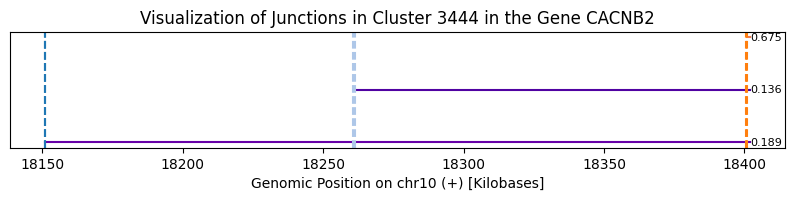

In [47]:
#from LeafletSC.clustering.find_intron_clusters import visualize_junctions
junc_id = dat_vis.junction_id.sample(1).values[0]
j = junc_id
j = "10_18150975_18401923"
visualize_local_events(dat_vis, j, p_usage_ratio=True)

In [13]:
# extract all the unique gene names in all_juncs_df
gene_names = dat_vis.gene_name.unique()
print(len(gene_names))

3293


In [14]:
# find outliers in all_juncs_df.score using outlier formula anything above 1.5*IQR is an outlier
Q1 = dat_vis.counts_total.quantile(0.25)
Q3 = dat_vis.counts_total.quantile(0.75)
IQR = Q3 - Q1
outliers = dat_vis[(dat_vis.counts_total < (Q1 - 1.5 * IQR)) | (dat_vis.counts_total > (Q3 + 1.5 * IQR))]
print(IQR)

218.0


In [15]:
outliers.counts_total.min()

613

In [16]:
print(f"The number of outliers (junction counts_total) in the data is: {len(outliers)}")

The number of outliers (junction counts_total) in the data is: 1290


In [17]:
print(f"The totaln number of junctions in the data is: {len(dat_vis)}")

The totaln number of junctions in the data is: 12749


In [18]:
print(f"Percentage of outliers in the data is: {len(outliers)/len(dat_vis)*100}")

Percentage of outliers in the data is: 10.118440662012706


Text(0, 0.5, 'Number of junctions')

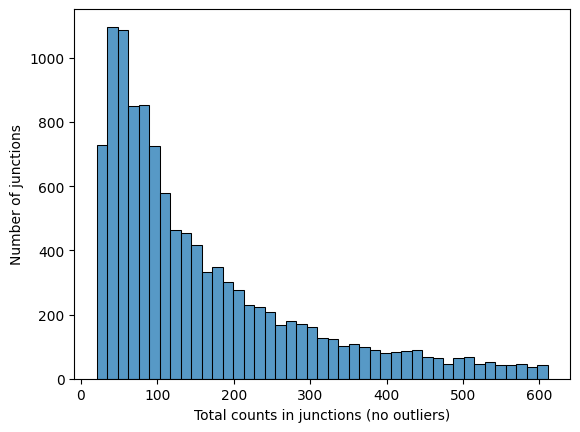

In [19]:
nonoutliers = dat_vis[(dat_vis.counts_total < (Q3 + 1.5 * IQR))]

# xlab is total counts in junctions (non outliers)
# ylab is number of junctions 

xlabel = "Total counts in junctions (no outliers)"
ylabel = "Number of junctions"
sns.histplot(nonoutliers.counts_total)
plt.xlabel(xlabel)
plt.ylabel(ylabel)

In [20]:
# get average number of junctions per cluster here 
avg_juncs_per_cluster = dat_vis.groupby("Cluster").size().mean()
print("The average number of junctions per cluster is: " + str(avg_juncs_per_cluster))

The average number of junctions per cluster is: 2.725892666239042


### Now let's convert the intron clusters to a format that can be used by LeafletSC

In [21]:
intron_clusters = "/gpfs/commons/datasets/controlled/BRAIN_NeMO/human-cortex-mtg/LeafletAnalysis/human_cortex_mtg_leaflet_50_500000_20_20240510_single_cell.gz" # path to the intron clusters file
output_file = output_path + "human_cortex_mtg_leaflet" # name of the output file
has_genes = "yes" # since we used a gtf file to obtain the intron clusters, we can set this to yes
chunk_size = 5000 # number of junctions to process at a time from the intron clusters files
metadata = None # can replace with path, if metadata is available for cells (cell type, origin, library ID...)

In [22]:
prep_model_input(intron_clusters, output_file, has_genes, chunk_size, metadata)

The intron clusters file you provided is /gpfs/commons/datasets/controlled/BRAIN_NeMO/human-cortex-mtg/LeafletAnalysis/human_cortex_mtg_leaflet_50_500000_20_20240510_single_cell.gz, reading in chunks of 5000 lines
Processing intron clusters


67it [00:03, 20.73it/s]


Done processing intron clusters
The number of intron clusters evaluated is 4677
The number of junctions evaluated is 12749
The number of cells evaluated is 208
The number of clusters with only one junction is 0
A gtf file was used to generate intron clusters
The number of total cells evaluated is 208
The number of cells per cell type is:
cell_type
/gpfs/commons/datasets/controlled/BRAIN_NeMO/human-cortex-mtg/Leaflet/F2S4_170405_005_A01_junctions_with_barcodes.bed    1
/gpfs/commons/datasets/controlled/BRAIN_NeMO/human-cortex-mtg/Leaflet/F2S4_170405_005_B01_junctions_with_barcodes.bed    1
/gpfs/commons/datasets/controlled/BRAIN_NeMO/human-cortex-mtg/Leaflet/F2S4_170405_005_C01_junctions_with_barcodes.bed    1
/gpfs/commons/datasets/controlled/BRAIN_NeMO/human-cortex-mtg/Leaflet/F2S4_170405_005_D01_junctions_with_barcodes.bed    1
/gpfs/commons/datasets/controlled/BRAIN_NeMO/human-cortex-mtg/Leaflet/F2S4_170405_005_E01_junctions_with_barcodes.bed    1
                                   

### Take a quick look at the input file that will go into the model to get familiarized with all the columns

In [23]:
model_input_data = "/gpfs/commons/datasets/controlled/BRAIN_NeMO/human-cortex-mtg/LeafletAnalysis/human_cortex_mtg_leaflet.h5"
summarized_data = pd.read_hdf(model_input_data, 'df')
print(summarized_data.head())

                                             cell_id  Cluster  Cluster_Counts  \
0  F2S4_170405_005_A01_/gpfs/commons/datasets/con...        4               2   
1  F2S4_170405_005_A01_/gpfs/commons/datasets/con...        5               9   
2  F2S4_170405_005_A01_/gpfs/commons/datasets/con...        7               8   
3  F2S4_170405_005_A01_/gpfs/commons/datasets/con...       20               4   
4  F2S4_170405_005_A01_/gpfs/commons/datasets/con...       35               7   

             junction_id             gene_id  junc_count  \
0  1_150150287_150150911  ENSG00000023902.14           2   
1  1_150151058_150158818  ENSG00000023902.14           9   
2    1_69678478_69760190  ENSG00000033122.21           8   
3    1_16970767_16971464  ENSG00000058453.17           4   
4  1_172551626_172553259  ENSG00000094975.15           6   

                                           cell_type  junc_ratio  \
0  /gpfs/commons/datasets/controlled/BRAIN_NeMO/h...    1.000000   
1  /gpfs/commons

In [24]:
# clean up the cell_id column, keep only the first part before "_/"
cell_ids = summarized_data.cell_id.unique()

# clean up the cell_ids values to keep only the first part before "_/"
cell_ids_clean = [c.split("_/")[0] for c in cell_ids]

# make dataframe of old and clean cell_ids and merge wtih summarized_data
cell_ids_df = pd.DataFrame({"cell_id": cell_ids, "cell_id_clean": cell_ids_clean})
summarized_data = summarized_data.merge(cell_ids_df, on="cell_id")

# remove cell_id column and rename cell_id_clean to cell_id column
summarized_data = summarized_data.drop(columns=["cell_id"])
summarized_data = summarized_data.rename(columns={"cell_id_clean": "cell_id"})

In [25]:
# now let's see how many junctions are detected in a single cell 
junctions_per_cell = summarized_data.groupby("cell_id").size()
total_num_juncs = summarized_data.junction_id.nunique()

# get percentage of junctions detected in a single cell
percentage_juncs_per_cell = junctions_per_cell/total_num_juncs * 100
percentage_juncs_per_cell = percentage_juncs_per_cell.reset_index()
percentage_juncs_per_cell.columns = ["cell_id", "percentage_junctions"]

# add also the number of junctions detected in a single cell
junctions_per_cell = junctions_per_cell.reset_index()
junctions_per_cell.columns = ["cell_id", "num_junctions"]

# get also number of unique gene_ids detected in a single cell 
unique_genes_per_cell = summarized_data.groupby("cell_id").gene_id.nunique()
unique_genes_per_cell = unique_genes_per_cell.reset_index()
unique_genes_per_cell.columns = ["cell_id", "num_genes"]

# get also number of unique Cluster detected in a single cell
unique_clusters_per_cell = summarized_data.groupby("cell_id").Cluster.nunique()
unique_clusters_per_cell = unique_clusters_per_cell.reset_index()
unique_clusters_per_cell.columns = ["cell_id", "num_clusters"]

# num of cells a junction is detected in 
cells_per_junc = summarized_data.groupby("junction_id").size()
cells_per_junc = cells_per_junc.reset_index()
cells_per_junc.columns = ["junction_id", "num_cells"]
cells_per_junc

,junction_id,num_cells
0,10_100185637_100185903,5
1,10_100185637_100185961,11
2,10_100190968_100192458,9
3,10_100190968_100193297,5
4,10_100253539_100256261,10
...,...,...
12744,Y_5000605_5056888,17
12745,Y_5032011_5032669,13
12746,Y_5032728_5056888,24
12747,Y_57209729_57209821,28


In [26]:
cells_per_junc.num_cells.min()

5

Text(0, 0.5, '# of junctions')

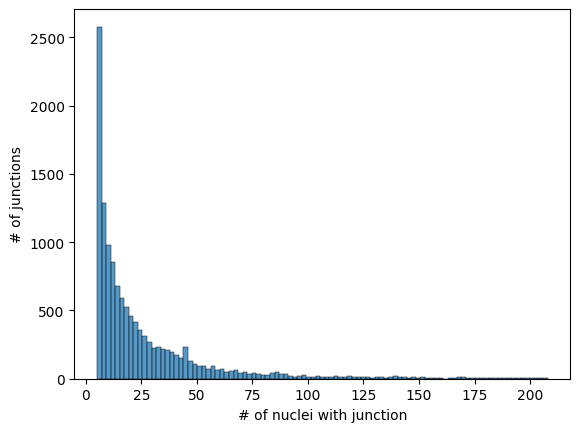

In [27]:
# make a histogram 
sns.histplot(cells_per_junc.num_cells)
xlab="# of nuclei with junction"
ylab="# of junctions"
plt.xlabel(xlab)
plt.ylabel(ylab)

Text(0, 0.5, '# of nuclei')

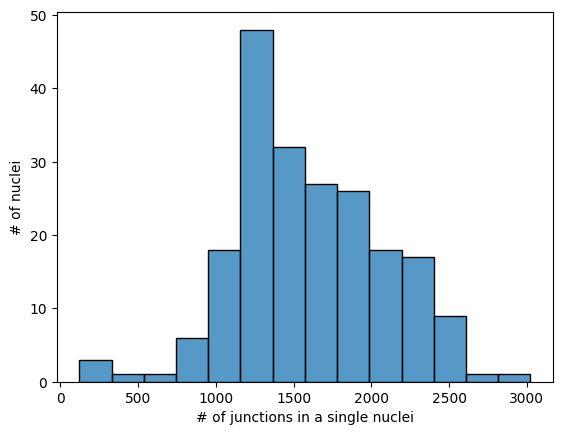

In [28]:
# make a histogram 
sns.histplot(junctions_per_cell.num_junctions)
xlab="# of junctions in a single nuclei"
ylab="# of nuclei"
plt.xlabel(xlab)
plt.ylabel(ylab)

Text(0, 0.5, '# of nuclei')

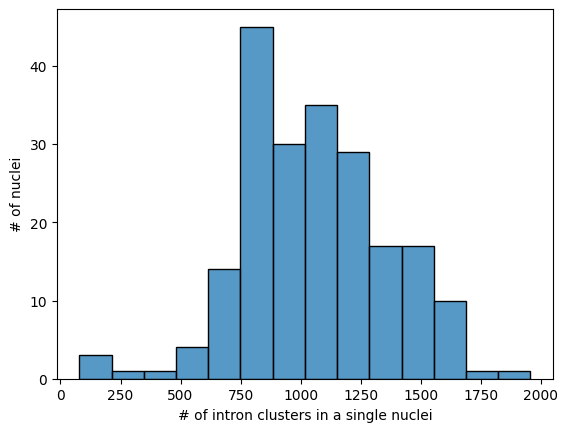

In [29]:
# make a histogram 
sns.histplot(unique_clusters_per_cell.num_clusters)
xlab="# of intron clusters in a single nuclei"
ylab="# of nuclei"
plt.xlabel(xlab)
plt.ylabel(ylab)

Text(0, 0.5, '# of nuclei')

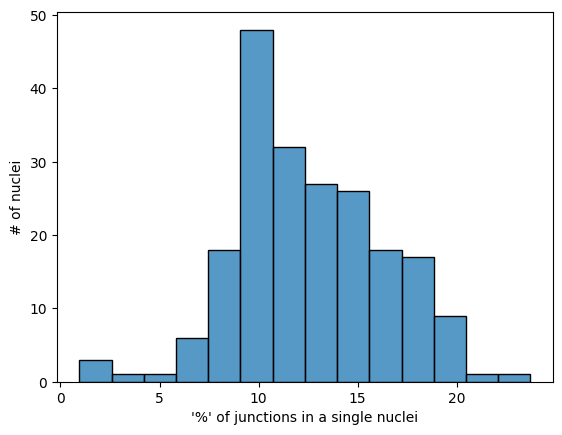

In [30]:
# make a histogram 
sns.histplot(percentage_juncs_per_cell.percentage_junctions)
xlab="'%' of junctions in a single nuclei"
ylab="# of nuclei"
plt.xlabel(xlab)
plt.ylabel(ylab)

Text(0, 0.5, '# of nuclei')

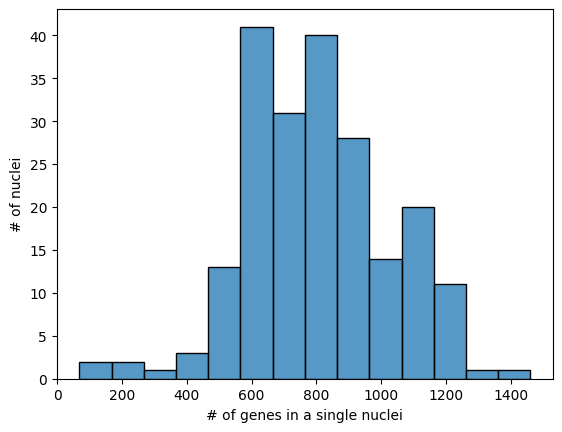

In [31]:
# make a histogram 
sns.histplot(unique_genes_per_cell.num_genes)
xlab="# of genes in a single nuclei"
ylab="# of nuclei"
plt.xlabel(xlab)
plt.ylabel(ylab)

<Axes: xlabel='junc_ratio', ylabel='Count'>

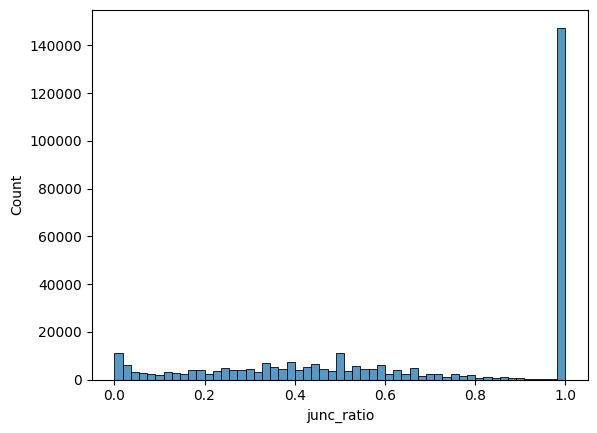

In [32]:
# make a histogram of junction ratios
sns.histplot(summarized_data.junc_ratio)

In [33]:
summarized_data.head()

,Cluster,Cluster_Counts,junction_id,gene_id,junc_count,cell_type,junc_ratio,cell_id_index,junction_id_index,cell_id
0,4,2,1_150150287_150150911,ENSG00000023902.14,2,/gpfs/commons/datasets/controlled/BRAIN_NeMO/h...,1.000000,0,5149,F2S4_170405_005_A01
1,5,9,1_150151058_150158818,ENSG00000023902.14,9,/gpfs/commons/datasets/controlled/BRAIN_NeMO/h...,1.000000,0,5151,F2S4_170405_005_A01
2,7,8,1_69678478_69760190,ENSG00000033122.21,8,/gpfs/commons/datasets/controlled/BRAIN_NeMO/h...,1.000000,0,6064,F2S4_170405_005_A01
3,20,4,1_16970767_16971464,ENSG00000058453.17,4,/gpfs/commons/datasets/controlled/BRAIN_NeMO/h...,1.000000,0,5351,F2S4_170405_005_A01
4,35,7,1_172551626_172553259,ENSG00000094975.15,6,/gpfs/commons/datasets/controlled/BRAIN_NeMO/h...,0.857143,0,5369,F2S4_170405_005_A01


In [34]:
cells_pub.iloc[0]

sample_name                      F1S4_160106_001_B01
sample_id                                  556012415
sample_type                                   Nuclei
organism                                Homo sapiens
donor                                      H200.1030
sex                                                M
age_days                                       19710
brain_hemisphere                                   L
brain_region                                     MTG
brain_subregion                                   L5
facs_date                                     1/6/16
facs_container                       F1S4_160106_001
facs_sort_criteria                     NeuN-positive
rna_amplification_set                 A8S4_160401_02
library_prep_set                      L8S4_160406_02
library_prep_avg_size_bp                         429
seq_name                          LS-15051_S02_E1-50
seq_tube                                    LS-15051
seq_batch                              R8S4-16

In [35]:
cells_pub["cell_id"] = cells_pub["sample_name"]
cells_pub["cell_type"] = cells_pub["class"]
cells_info = cells_pub[["cell_id", "cell_type"]]

In [36]:
# remove cell type column from summarized_data 
summarized_data = summarized_data.drop(columns=["cell_type"])

In [37]:
cells_info.cell_type.value_counts()

cell_type
Glutamatergic    10525
GABAergic         4164
Non-neuronal       914
no class           325
Name: count, dtype: int64

In [38]:
# now merge with cells_pub on cell_id
summarized_data = summarized_data.merge(cells_info, on="cell_id")

In [39]:
summarized_data.to_hdf(model_input_data, key='df', mode='w', complevel=9, complib='zlib', format="table")  

In [40]:
model_input_data

'/gpfs/commons/datasets/controlled/BRAIN_NeMO/human-cortex-mtg/LeafletAnalysis/human_cortex_mtg_leaflet.h5'

In [41]:
summarized_data

,Cluster,Cluster_Counts,junction_id,gene_id,junc_count,junc_ratio,cell_id_index,junction_id_index,cell_id,cell_type
0,4,2,1_150150287_150150911,ENSG00000023902.14,2,1.000000,0,5149,F2S4_170405_005_A01,no class
1,5,9,1_150151058_150158818,ENSG00000023902.14,9,1.000000,0,5151,F2S4_170405_005_A01,no class
2,7,8,1_69678478_69760190,ENSG00000033122.21,8,1.000000,0,6064,F2S4_170405_005_A01,no class
3,20,4,1_16970767_16971464,ENSG00000058453.17,4,1.000000,0,5351,F2S4_170405_005_A01,no class
4,35,7,1_172551626_172553259,ENSG00000094975.15,6,0.857143,0,5369,F2S4_170405_005_A01,no class
...,...,...,...,...,...,...,...,...,...,...
333193,6338,37,Y_12686606_12690325,ENSG00000114374.13,8,0.216216,207,12708,F2S4_170405_032_H01,GABAergic
333194,6338,37,Y_12690441_12702009,ENSG00000114374.13,7,0.189189,207,12710,F2S4_170405_032_H01,GABAergic
333195,6339,36,Y_12702055_12708633,ENSG00000114374.13,15,0.416667,207,12712,F2S4_170405_032_H01,GABAergic
333196,6339,36,Y_12702055_12709387,ENSG00000114374.13,5,0.138889,207,12713,F2S4_170405_032_H01,GABAergic


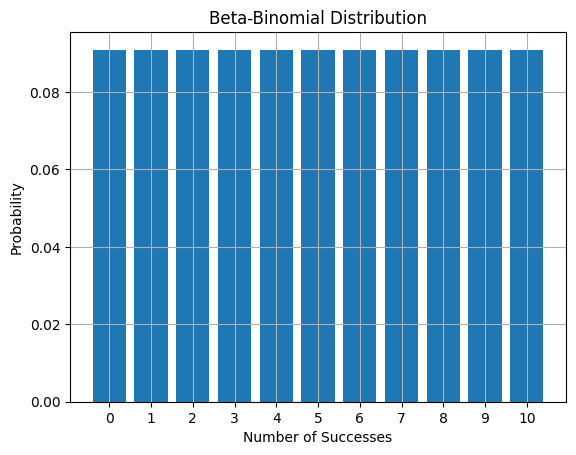

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import betabinom

# Parameters for the beta-binomial distribution
n = 10  # number of trials
a = 1   # concentration parameter for the beta distribution
b = 1   # concentration parameter for the beta distribution

# Generate values for the x-axis (number of successes)
x = np.arange(0, n+1)

# Calculate the probability mass function (PMF) of the beta-binomial distribution
pmf = betabinom.pmf(x, n, a, b)

# Plot the beta-binomial distribution
plt.bar(x, pmf)
plt.title('Beta-Binomial Distribution')
plt.xlabel('Number of Successes')
plt.ylabel('Probability')
plt.xticks(x)
plt.grid(True)
plt.show()
